Max closure residual |E^2-(Om+OL+Or)| = 5.960e-08
H(a=1) approx = 73.000000 km/s/Mpc


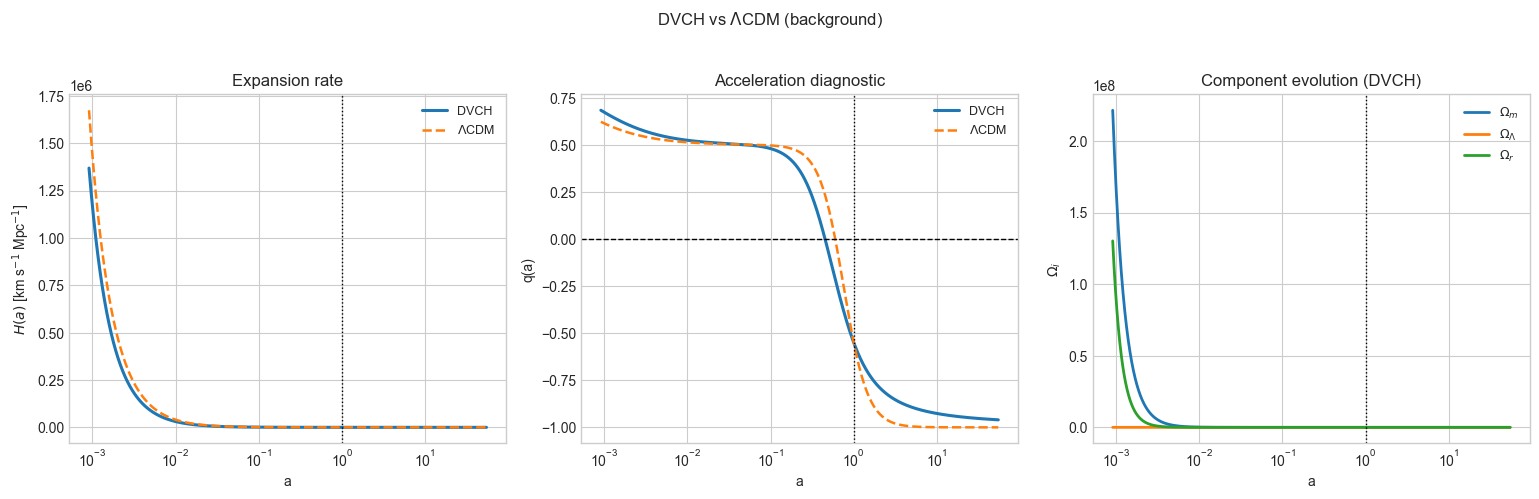

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs_dvch(N, Y, n, beta):
    om_m, om_l, om_r = Y

    om_m = max(om_m, 1e-15)
    om_l = max(om_l, 0.0)
    om_r = max(om_r, 0.0)

    e2 = max(om_m + om_l + om_r, 1e-20)
    e = np.sqrt(e2)

    b_term = n - (beta / (1.0 + beta * e2)) * ((4.0 * om_r + 3.0 * om_m) / 3.0)
    qtilde = -e * om_l / (1.0 + n * om_l / om_m) * b_term

    dom_m_dN = -3.0 * om_m - 3.0 * qtilde / e
    dom_l_dN = +3.0 * qtilde / e
    dom_r_dN = -4.0 * om_r
    return [dom_m_dN, dom_l_dN, dom_r_dN]


def _integrate_branch(n_span, y0, n, beta, npts):
    n_eval = np.linspace(n_span[0], n_span[1], npts)
    sol = solve_ivp(
        fun=lambda n_var, y_var: rhs_dvch(n_var, y_var, n=n, beta=beta),
        t_span=n_span,
        y0=y0,
        t_eval=n_eval,
        rtol=1e-9,
        atol=1e-12,
        method="RK45",
    )
    if not sol.success:
        raise RuntimeError(f"Integration failed on span {n_span}: {sol.message}")
    return sol.t, sol.y


def solve_dvch(H0=73.0, Om0=0.30, Or0=9e-5, n=0.2, beta=1e-4, Nmin=-7.0, Nmax=4.0, npts=5000):
    ol0 = 1.0 - Om0 - Or0
    y0 = [Om0, ol0, Or0]

    npts_back = max(2, npts // 2)
    npts_forw = max(2, npts - npts_back + 1)

    # Integrar desde hoy (N=0) hacia pasado y futuro
    n_back, y_back = _integrate_branch((0.0, Nmin), y0, n, beta, npts_back)
    n_forw, y_forw = _integrate_branch((0.0, Nmax), y0, n, beta, npts_forw)

    # Empalme sin duplicar N=0
    n_all = np.concatenate([n_back[::-1], n_forw[1:]])
    y_all = np.concatenate([y_back[:, ::-1], y_forw[:, 1:]], axis=1)

    om_m, om_l, om_r = y_all
    e2 = np.maximum(om_m + om_l + om_r, 1e-20)
    e = np.sqrt(e2)

    a = np.exp(n_all)
    H = H0 * e
    q = -1.0 - np.gradient(np.log(e), n_all)

    return {"N": n_all, "a": a, "E": e, "H": H, "q": q, "Om": om_m, "OL": om_l, "Or": om_r}


def solve_lcdm(H0=73.0, Om0=0.30, Or0=9e-5, Nmin=-7.0, Nmax=4.0, npts=5000):
    N = np.linspace(Nmin, Nmax, npts)
    a = np.exp(N)
    OL0 = 1.0 - Om0 - Or0
    E = np.sqrt(Om0 * a**(-3) + Or0 * a**(-4) + OL0)
    H = H0 * E
    q = -1.0 - np.gradient(np.log(E), N)
    return {"N": N, "a": a, "E": E, "H": H, "q": q}


# -------------------- Ejecutar --------------------
pars = dict(H0=73.0, Om0=0.30, Or0=9e-5, n=0.2, beta=1e-4, Nmin=-7.0, Nmax=4.0, npts=5000)

dv = solve_dvch(**pars)
lc = solve_lcdm(H0=pars["H0"], Om0=pars["Om0"], Or0=pars["Or0"], Nmin=pars["Nmin"], Nmax=pars["Nmax"], npts=pars["npts"])

# Chequeos rápidos
closure_max = np.max(np.abs(dv["E"]**2 - (dv["Om"] + dv["OL"] + dv["Or"])))
print(f"Max closure residual |E^2-(Om+OL+Or)| = {closure_max:.3e}")
print(f"H(a=1) approx = {np.interp(1.0, dv['a'], dv['H']):.6f} km/s/Mpc")

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.8))

ax[0].plot(dv["a"], dv["H"], lw=2.2, label="DVCH")
ax[0].plot(lc["a"], lc["H"], "--", lw=1.8, label=r"$\Lambda$CDM")
ax[0].set_xscale("log")
ax[0].axvline(1, color="k", ls=":", lw=1)
ax[0].set_xlabel("a")
ax[0].set_ylabel(r"$H(a)$ [km s$^{-1}$ Mpc$^{-1}$]")
ax[0].set_title("Expansion rate")
ax[0].legend(fontsize=9)

ax[1].plot(dv["a"], dv["q"], lw=2.2, label="DVCH")
ax[1].plot(lc["a"], lc["q"], "--", lw=1.8, label=r"$\Lambda$CDM")
ax[1].set_xscale("log")
ax[1].axhline(0, color="k", ls="--", lw=1)
ax[1].axvline(1, color="k", ls=":", lw=1)
ax[1].set_xlabel("a")
ax[1].set_ylabel("q(a)")
ax[1].set_title("Acceleration diagnostic")
ax[1].legend(fontsize=9)

ax[2].plot(dv["a"], dv["Om"], lw=2.0, label=r"$\Omega_m$")
ax[2].plot(dv["a"], dv["OL"], lw=2.0, label=r"$\Omega_\Lambda$")
ax[2].plot(dv["a"], dv["Or"], lw=2.0, label=r"$\Omega_r$")
ax[2].set_xscale("log")
ax[2].axvline(1, color="k", ls=":", lw=1)
ax[2].set_xlabel("a")
ax[2].set_ylabel(r"$\Omega_i$")
ax[2].set_title("Component evolution (DVCH)")
ax[2].legend(fontsize=9)

fig.suptitle(r"DVCH vs $\Lambda$CDM (background)", y=1.03)
plt.tight_layout()
plt.savefig("Fig_DVCH_correcta.pdf", format="pdf", bbox_inches="tight")
plt.savefig("Fig_DVCH_correcta.png", dpi=300, bbox_inches="tight")
plt.show()